# Bayesian Panel Data Model - Life Expectancy

This notebook implements a Bayesian hierarchical panel model to analyze Life Expectancy gender gaps using both temporal variation and cross-country variation simultaneously. The temporal range is configurable (default: 2000-2019, can be extended to 2023 to include COVID years). Data source: OWID Life Expectancy (2000-2023), pre-cleaned in `eda.md`.

## Overview

The panel data approach provides more statistical power and allows us to model how relationships between indicators and gender gaps evolve over time, while accounting for country-specific characteristics.

**Model Structure:**
- Bayesian hierarchical model with country-level random intercepts
- Shared slopes for all predictors (same across all countries)
- Uses both within-country and between-country variation
- Controls for time-invariant country-level factors

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az

from utils import (
    decorate, underride, configure_plot_style,
    write_html_table, log_and_print, set_log_file
)

configure_plot_style()

/home/downey/miniconda3/envs/LifeExpectancy/lib/python3.11/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
from utils import setup_beep_on_error
setup_beep_on_error()

## Model Configuration

In [4]:
# ============================================================================
# MODEL CONFIGURATION: TEMPORAL CUTOFF AND COVID DATA
# ============================================================================
# Global variable: Whether to include COVID-19 data as a predictor
# Set to True to include COVID-19 death rates as a predictor and extend analysis to 2023
# Set to False to exclude COVID-19 and use pre-COVID baseline (2000-2019)
INCLUDE_COVID_DATA = True

# Cutoff year is automatically determined by COVID flag
# OWID LE extends to 2023
# True -> 2023 (includes all COVID years), False -> 2019 (pre-COVID baseline)
CUTOFF_YEAR = 2023 if INCLUDE_COVID_DATA else 2019

# Global variable: List of countries to exclude from analysis
# Set to empty list [] to include all countries
COUNTRIES_TO_EXCLUDE = ['TUR']

print(f"Model Configuration:")
print(f"  LE Data Source: OWID (HMD + UN WPP, 2000-2023)")
print(f"  Include COVID Data: {INCLUDE_COVID_DATA}")
print(f"  Cutoff Year: {CUTOFF_YEAR} (automatically set based on COVID flag)")
print(f"  Countries Excluded: {COUNTRIES_TO_EXCLUDE}")

Model Configuration:
  LE Data Source: OWID (HMD + UN WPP, 2000-2023)
  Include COVID Data: True
  Cutoff Year: 2023 (automatically set based on COVID flag)
  Countries Excluded: ['TUR']


In [5]:
# Setup logging
import os
os.makedirs('logs', exist_ok=True)
os.makedirs('../output/tables', exist_ok=True)
os.makedirs('../output/figs', exist_ok=True)

# Create descriptive log filename
covid_suffix = 'with_covid' if INCLUDE_COVID_DATA else 'pre_covid'
log_path = f'logs/bayesian_model_le_{covid_suffix}_{CUTOFF_YEAR}.txt'

log_file = open(log_path, 'w')
set_log_file(log_file)
print(f"Logging to: {log_path}")

# Log configuration
log_and_print("="*80)
log_and_print("BAYESIAN PANEL MODEL - LIFE EXPECTANCY GENDER GAPS")
log_and_print("="*80)
log_and_print(f"Timestamp: {pd.Timestamp.now()}")
log_and_print(f"Include COVID Data: {INCLUDE_COVID_DATA}")
log_and_print(f"Analysis Period: 2000-{CUTOFF_YEAR}")
log_and_print(f"Countries Excluded: {COUNTRIES_TO_EXCLUDE}")
log_and_print("="*80)

Logging to: logs/bayesian_model_le_with_covid_2023.txt
BAYESIAN PANEL MODEL - LIFE EXPECTANCY GENDER GAPS
Timestamp: 2026-01-29 11:38:15.537138
Include COVID Data: True
Analysis Period: 2000-2023
Countries Excluded: ['TUR']


## Load Panel Data

The panel dataset is created by `process.ipynb` and saved to CSV (avoiding HDF5 Arrow string issues with PyMC).

In [6]:
# Load panel data from CSV (created by process.ipynb)
panel_csv_file = '../data/panel_le.csv'
panel_le = pd.read_csv(panel_csv_file)

print(f"Panel data loaded from: {panel_csv_file}")
print(f"Shape: {panel_le.shape}")
print(f"Countries: {panel_le['country'].nunique()}")
print(f"Years: {panel_le['Year'].min():.0f}-{panel_le['Year'].max():.0f}")
print(f"Missing values: {panel_le.isnull().sum().sum()}")
panel_le.head()

Panel data loaded from: ../data/panel_le.csv
Shape: (888, 27)
Countries: 37
Years: 2000-2023
Missing values: 0


,country,Year,LE_gap,Mid_Alcohol,Gap_Alcohol,Mid_Suicide,Gap_Suicide,Mid_Homicide,Gap_Homicide,Mid_RoadTraffic,...,Mid_ChronicRespiratory,Gap_ChronicRespiratory,Mid_LiverDisease,Gap_LiverDisease,Mid_UnintentionalInjury,Gap_UnintentionalInjury,Mid_DrugDisorder,Gap_DrugDisorder,Mid_COVID,Gap_COVID
0,AUS,2000,5.3258,1.683177,2.103379,13.629919,16.004763,1.733778,1.026409,10.634210,...,40.367064,13.900258,6.701960,5.152012,13.376072,2.686396,5.334618,4.903885,0.0,0.0
1,AUS,2001,5.2164,1.633888,2.035051,13.245450,15.135181,1.684873,1.058054,10.228433,...,39.770878,12.465605,6.731144,5.404421,12.965122,2.282112,4.523167,3.717160,0.0,0.0
2,AUS,2002,4.9902,1.692577,2.040075,12.521057,14.072718,1.587996,1.014458,9.767470,...,40.685314,11.827239,7.122281,5.530302,13.951452,2.509564,4.055073,3.111505,0.0,0.0
3,AUS,2003,4.9644,1.683623,2.005382,11.874770,13.449123,1.385104,0.990465,9.220344,...,39.185032,10.164146,7.207535,5.868847,14.468874,2.917728,3.865444,2.889375,0.0,0.0
4,AUS,2004,4.9009,1.665497,1.922664,11.535865,13.224887,1.127007,0.736941,8.914215,...,37.758441,8.752940,7.249300,5.947368,15.340847,2.725826,3.761432,2.807344,0.0,0.0


In [7]:
# Log panel data summary
log_and_print("\n" + "="*80)
log_and_print("PANEL DATA LOADED")
log_and_print("="*80)
log_and_print(f"Source: {panel_csv_file}")
log_and_print(f"Shape: {panel_le.shape}")
log_and_print(f"Countries: {panel_le['country'].nunique()}")
log_and_print(f"Years: {panel_le['Year'].min():.0f}-{panel_le['Year'].max():.0f}")
log_and_print(f"Missing values: {panel_le.isnull().sum().sum()}")
log_and_print("="*80)


PANEL DATA LOADED
Source: ../data/panel_le.csv
Shape: (888, 27)
Countries: 37
Years: 2000-2023
Missing values: 0


## Prepare Panel Data for Modeling

Now we'll use the `prepare_panel_data` function to standardize predictors and center targets:

In [8]:
def prepare_panel_data(df, predictor_cols, target_col):
    """
    Prepare panel data for Bayesian modeling.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Long-format DataFrame with columns:
        - 'country' (str)
        - 'year' (int)
        - target_col (float, HALE_gap or LE_gap in years)
        - predictor_cols (float)
    
    Returns
    -------
    data_dict : dict
        Dictionary with:
            X          : (N, P) ndarray of standardized predictors
            y_centered : (N,) ndarray of centered target
            country_idx: (N,) int array in [0, n_country-1]
            year_idx   : (N,) int array in [0, n_year-1]
            coords     : dict for PyMC Model(coords=...)
            meta       : dict with means/SDs for later use
    """
    df = df.copy()
    
    # Unique levels
    countries = sorted(df["country"].unique())
    years = sorted(df["year"].unique())
    predictors = list(predictor_cols)
    
    country_indexer = {c: i for i, c in enumerate(countries)}
    year_indexer = {y: i for i, y in enumerate(years)}
    
    df["country_idx"] = df["country"].map(country_indexer)
    df["year_idx"] = df["year"].map(year_indexer)
    
    # Extract raw matrices/vectors
    X_raw = df[predictor_cols].to_numpy(dtype=float)
    y_raw = df[target_col].to_numpy(dtype=float)
    country_idx = df["country_idx"].to_numpy(dtype=int)
    year_idx = df["year_idx"].to_numpy(dtype=int)
    
    # Standardize predictors across all country–year rows
    X_mean = X_raw.mean(axis=0)
    X_std = X_raw.std(axis=0, ddof=0)
    # Guard against any zero variance columns
    X_std_safe = np.where(X_std == 0, 1.0, X_std)
    X = (X_raw - X_mean) / X_std_safe
    
    # Center target (keep units in years)
    y_mean = y_raw.mean()
    y_centered = y_raw - y_mean
    
    N, P = X.shape
    
    coords = {
        "obs": np.arange(N),
        "country": countries,
        "year": years,
        "predictor": predictors,
    }
    
    data_dict = {
        "X": X,
        "y_centered": y_centered,
        "country_idx": country_idx,
        "year_idx": year_idx,
        "coords": coords,
        "meta": {
            "X_mean": X_mean,
            "X_std": X_std_safe,
            "y_mean": y_mean,
            "countries": countries,
            "years": years,
            "predictors": predictors,
        },
    }
    
    return data_dict

In [9]:
# ============================================================================
# MODEL CONFIGURATION
# ============================================================================
# Configure which Mid predictors to include in the model
# Options: [] (baseline - Gap predictors only)
#          ['Mid_Cardiovascular'] (add Mid_Cardiovascular)
#          ['Mid_Cardiovascular', 'Mid_Diabetes'] (add multiple)
#          etc.
#
# Testing order (from plan.md):
#   1. Mid_Cardiovascular (r = -0.804 with Gap_Cardiovascular)
#   2. Mid_Diabetes (r = -0.325 with Gap_Diabetes)
#   3. Mid_ChronicRespiratory (r = -0.0787 with Gap_ChronicRespiratory)
#   4. Mid_UnintentionalInjury (r = 0.0346 with Gap_UnintentionalInjury)
#
# Start with baseline: MID_PREDICTORS_TO_INCLUDE = []
# Then test each candidate one at a time, adding to list if it improves model
#
# Experiment status (from original HALE/LE analysis):
#   - Baseline ([]): ✅ OPTIMAL MODEL
#   - Adding Mid predictors worsened fit
#   - ALL EXPERIMENTS COMPLETE: Baseline model (Gap predictors only) is optimal
# ============================================================================
MID_PREDICTORS_TO_INCLUDE = []  # Final model: Gap predictors only (baseline)  

# Global variable: Whether to include year effects (Gaussian Random Walk)
# Set to True to include year effects to control for global temporal trends
# Set to False to exclude year effects (current model)
INCLUDE_YEAR_EFFECTS = False

# Helper function to generate output filenames with appropriate suffix
def get_output_filename(base_path, mid_predictors_list=None, include_year_effects=False, 
                        cutoff_year=None, include_covid_data=None):
    """
    Generate output filename with appropriate suffixes based on configuration.
    
    Parameters
    ----------
    base_path : str
        Base file path (e.g., '../output/tables/beta_coefficients_le.html')
    mid_predictors_list : list, optional
        List of Mid predictors to include (e.g., ['Mid_Cardiovascular'])
        If None or empty, uses 'nomid' suffix
    include_year_effects : bool
        Whether year effects (GRW) are included in the model
    cutoff_year : int, optional
        Cutoff year for analysis. If None, uses global CUTOFF_YEAR.
    include_covid_data : bool, optional
        Whether COVID data is included. If None, uses global INCLUDE_COVID_DATA.
        
    Returns
    -------
    filename : str
        Filename with appropriate suffixes inserted before extension
        Example: 'beta_coefficients_le_nomid_nogrw_y2019_nocovid.html'
    """
    import os
    path_parts = base_path.rsplit('.', 1)
    has_ext = len(path_parts) == 2
    
    # Use global values if not provided
    if cutoff_year is None:
        cutoff_year = CUTOFF_YEAR
    if include_covid_data is None:
        include_covid_data = INCLUDE_COVID_DATA
    
    # Generate Mid predictor suffix
    if mid_predictors_list is None or len(mid_predictors_list) == 0:
        mid_suffix = 'nomid'
    else:
        # Create short names for each Mid predictor
        short_names = {
            'Mid_Cardiovascular': 'cardio',
            'Mid_Diabetes': 'diabetes',
            'Mid_ChronicRespiratory': 'respiratory',
            'Mid_UnintentionalInjury': 'unintentional',
            'Mid_Neoplasms': 'neoplasms',
        }
        # Generate suffix from list (e.g., 'midcardio_diabetes')
        mid_parts = []
        for mid_pred in sorted(mid_predictors_list):  # Sort for consistency
            short_name = short_names.get(mid_pred, mid_pred.replace('Mid_', '').lower())
            mid_parts.append(short_name)
        mid_suffix = 'mid' + '_'.join(mid_parts)
    
    # Generate year effects suffix
    grw_suffix = 'yesgrw' if include_year_effects else 'nogrw'
    
    # Generate cutoff year suffix
    year_suffix = f'y{cutoff_year}'
    
    # Generate COVID suffix
    covid_suffix = 'covid' if include_covid_data else 'nocovid'
    
    # Combine suffixes
    if has_ext:
        base, ext = path_parts
        return f"{base}_{mid_suffix}_{grw_suffix}_{year_suffix}_{covid_suffix}.{ext}"
    else:
        return f"{base_path}_{mid_suffix}_{grw_suffix}_{year_suffix}_{covid_suffix}"

# Prepare predictor columns (Gap predictors + selected Mid predictors)
# Start with all Gap predictors
predictor_cols = [col for col in panel_le.columns if col.startswith('Gap_')]

# Add selected Mid predictors
if MID_PREDICTORS_TO_INCLUDE:
    for mid_pred in MID_PREDICTORS_TO_INCLUDE:
        if mid_pred in panel_le.columns:
            predictor_cols.append(mid_pred)
            print(f"  Adding: {mid_pred}")
        else:
            print(f"  WARNING: {mid_pred} not found in panel columns")
    
    print(f"\nIncluding Mid predictors: YES ({len(MID_PREDICTORS_TO_INCLUDE)} predictor(s))")
    print(f"  Selected: {MID_PREDICTORS_TO_INCLUDE}")
else:
    print(f"Including Mid predictors: NO (Gap predictors only)")

print(f"\nNumber of predictors: {len(predictor_cols)}")
print(f"Predictors: {sorted(predictor_cols)}")

Including Mid predictors: NO (Gap predictors only)

Number of predictors: 12
Predictors: ['Gap_Alcohol', 'Gap_COVID', 'Gap_Cardiovascular', 'Gap_ChronicRespiratory', 'Gap_Diabetes', 'Gap_DrugDisorder', 'Gap_Homicide', 'Gap_LiverDisease', 'Gap_Neoplasms', 'Gap_RoadTraffic', 'Gap_Suicide', 'Gap_UnintentionalInjury']


In [10]:
# Prepare data for Life Expectancy gap model (uses panel_le)
panel_le_model = panel_le.rename(columns={'Year': 'year'})

data_le = prepare_panel_data(
    panel_le_model,
    predictor_cols=predictor_cols,
    target_col='LE_gap'
)

print(f"Life Expectancy model data:")
print(f"  Observations: {data_le['X'].shape[0]}")
print(f"  Predictors: {data_le['X'].shape[1]}")
print(f"  Countries: {len(data_le['coords']['country'])}")
print(f"  Years: {len(data_le['coords']['year'])}")
print(f"  Year range: {min(data_le['meta']['years'])}-{max(data_le['meta']['years'])}")
if COUNTRIES_TO_EXCLUDE:
    print(f"  Excluded: {COUNTRIES_TO_EXCLUDE}")

Life Expectancy model data:
  Observations: 888
  Predictors: 12
  Countries: 37
  Years: 24
  Year range: 2000-2023
  Excluded: ['TUR']


## Build Bayesian Model Function

Now we'll define the function to build the Bayesian hierarchical model with random intercepts:

In [11]:
def build_random_intercept_panel_model(data, include_year_effects=False):
    """
    Build a Bayesian hierarchical panel model with:
      - Random intercepts by country
      - Shared slopes for all predictors
      - Optional year effects (Gaussian Random Walk) to control for global temporal trends
      - Centered outcome y (LE_gap) in years
      - Standardized predictors
    
    Parameters
    ----------
    data : dict
        Output of prepare_panel_data(...)
    include_year_effects : bool
        If True, include Gaussian Random Walk year effects to control for global temporal trends
    
    Returns
    -------
    model : pymc.Model
        PyMC model object
    """
    X = data["X"]
    y_centered = data["y_centered"]
    country_idx = data["country_idx"]
    year_idx = data["year_idx"]
    coords = data["coords"]
    
    with pm.Model(coords=coords) as model:
        # Register index arrays and design matrix as Data
        country_idx_data = pm.Data("country_idx", country_idx, dims="obs")
        year_idx_data = pm.Data("year_idx", year_idx, dims="obs")
        X_data = pm.Data("X", X, dims=("obs", "predictor"))
        y_data = pm.Data("y", y_centered, dims="obs")
        
        # Hyperpriors for country intercepts
        mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=5.0)
        sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1.0)
        
        # Country-specific random intercepts
        alpha_raw = pm.Normal("alpha_raw", mu=0.0, sigma=1.0, dims="country")
        alpha = pm.Deterministic(
            "alpha",
            mu_alpha + alpha_raw * sigma_alpha,
            dims="country",
        )
        
        # Optional year effects (Gaussian Random Walk)
        if include_year_effects:
            # Standard deviation for random walk innovations
            sigma_gamma = pm.HalfNormal("sigma_gamma", sigma=0.5)
            # Gaussian Random Walk for year effects
            # init_dist specifies the distribution for the initial value
            # sigma=sigma_gamma controls the step size (innovation standard deviation)
            gamma = pm.GaussianRandomWalk(
                "gamma", 
                init_dist=pm.Normal.dist(mu=0.0, sigma=0.5),
                sigma=sigma_gamma, 
                dims="year"
            )
        else:
            gamma = None
        
        # Global slopes for standardized predictors
        beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="predictor")
        
        # Residual standard deviation (on y_centered scale, i.e., years)
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        
        # Linear predictor: random intercept by country + (optional) year effects + global slopes
        if include_year_effects:
            mu = pm.Deterministic(
                "mu",
                alpha[country_idx_data] + gamma[year_idx_data] + pm.math.dot(X_data, beta),
                dims="obs"
            )
        else:
            mu = pm.Deterministic(
                "mu",
                alpha[country_idx_data] + pm.math.dot(X_data, beta),
                dims="obs"
            )
        
        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data, dims="obs")
    
    return model

In [12]:
def add_log_likelihood_to_trace(model, trace):
    """
    Compute and add log-likelihood to trace for nutpie sampler.
    
    Note: nutpie doesn't save log-likelihood by default, so we need to
    compute it manually after sampling.
    
    Parameters
    ----------
    model : pymc.Model
        PyMC model object
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
        
    Returns
    -------
    trace : arviz.InferenceData
        Trace with log-likelihood added
    """
    with model:
        pm.compute_log_likelihood(trace)
    return trace

## Life Expectancy Gap Model

### Build Model

In [13]:
# Build model for Life Expectancy gap
model_le = build_random_intercept_panel_model(data_le, include_year_effects=INCLUDE_YEAR_EFFECTS)
if INCLUDE_YEAR_EFFECTS:
    print("Year effects (GRW): INCLUDED")
else:
    print("Year effects (GRW): NOT INCLUDED")

Year effects (GRW): NOT INCLUDED


### Sample from Posterior

In [14]:
# Sample from Life Expectancy model
with model_le:
    trace_le = pm.sample(
        nuts_sampler='nutpie'
    )

# Add log-likelihood for WAIC/LOO computation (nutpie doesn't save it by default)
trace_le = add_log_likelihood_to_trace(model_le, trace_le)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.23,31
,2000,0,0.24,63
,2000,0,0.26,79
,2000,0,0.28,47


Output()

In [15]:
# Log LE model summary
log_and_print("\n" + "="*80)
log_and_print("LIFE EXPECTANCY MODEL - SAMPLING COMPLETE")
log_and_print("="*80)
summary = az.summary(trace_le, var_names=["mu_alpha", "sigma_alpha", "sigma"])
log_and_print(f"Samples: {trace_le.posterior.sizes['draw']} draws x {trace_le.posterior.sizes['chain']} chains")
log_and_print(f"Max R-hat: {summary['r_hat'].max():.4f}")
log_and_print(f"Min ESS (bulk): {summary['ess_bulk'].min():.0f}")
log_and_print("="*80)


LIFE EXPECTANCY MODEL - SAMPLING COMPLETE
Samples: 1000 draws x 4 chains
Max R-hat: 1.0100
Min ESS (bulk): 877


### Model Diagnostics

Check convergence and sampling quality:

In [16]:
# Life Expectancy model diagnostics
az.summary(trace_le, var_names=["mu_alpha", "sigma_alpha", "sigma", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.002,0.107,-0.203,0.205,0.003,0.002,940.0,1276.0,1.00
sigma_alpha,0.647,0.088,0.492,0.820,0.003,0.002,877.0,1055.0,1.01
sigma,0.275,0.007,0.263,0.288,0.000,0.000,4394.0,2940.0,1.00
beta[Gap_Alcohol],0.138,0.033,0.077,0.202,0.001,0.001,3849.0,3149.0,1.00
beta[Gap_Suicide],0.365,0.042,0.283,0.440,0.001,0.001,3644.0,2735.0,1.00
beta[Gap_Homicide],0.441,0.024,0.398,0.487,0.000,0.000,4877.0,2637.0,1.00
beta[Gap_RoadTraffic],0.446,0.026,0.396,0.495,0.000,0.000,4018.0,2986.0,1.00
beta[Gap_Cardiovascular],-0.188,0.027,-0.238,-0.137,0.000,0.000,2960.0,2973.0,1.00
beta[Gap_Diabetes],-0.106,0.024,-0.150,-0.061,0.000,0.000,4636.0,3066.0,1.00
beta[Gap_Neoplasms],0.312,0.054,0.207,0.411,0.001,0.001,2505.0,2690.0,1.00


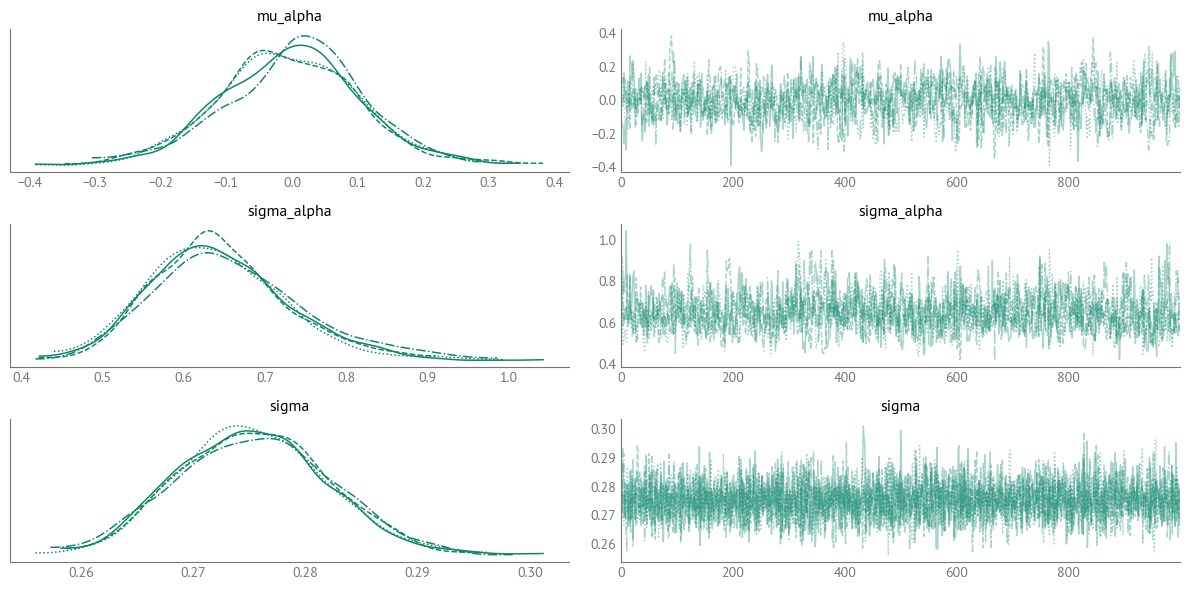

In [17]:
# Plot trace plots for key parameters (Life Expectancy)
az.plot_trace(trace_le, var_names=["mu_alpha", "sigma_alpha", "sigma"], compact=True)
plt.tight_layout()
plt.show()

### Posterior Analysis

Extract and analyze posterior distributions:

In [18]:
# Extract posterior means and credible intervals for beta coefficients (Life Expectancy)
beta_summary_le = az.summary(trace_le, var_names=["beta"])
beta_summary_le.index = data_le["meta"]["predictors"]
beta_summary_le

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Gap_Alcohol,0.138,0.033,0.077,0.202,0.001,0.001,3849.0,3149.0,1.0
Gap_Suicide,0.365,0.042,0.283,0.440,0.001,0.001,3644.0,2735.0,1.0
Gap_Homicide,0.441,0.024,0.398,0.487,0.000,0.000,4877.0,2637.0,1.0
Gap_RoadTraffic,0.446,0.026,0.396,0.495,0.000,0.000,4018.0,2986.0,1.0
Gap_Cardiovascular,-0.188,0.027,-0.238,-0.137,0.000,0.000,2960.0,2973.0,1.0
Gap_Diabetes,-0.106,0.024,-0.150,-0.061,0.000,0.000,4636.0,3066.0,1.0
Gap_Neoplasms,0.312,0.054,0.207,0.411,0.001,0.001,2505.0,2690.0,1.0
Gap_ChronicRespiratory,0.298,0.039,0.230,0.377,0.001,0.001,3880.0,2998.0,1.0
Gap_LiverDisease,0.250,0.033,0.190,0.310,0.001,0.000,4216.0,3206.0,1.0
Gap_UnintentionalInjury,0.160,0.040,0.086,0.233,0.001,0.001,3558.0,3012.0,1.0


In [19]:
# Write beta coefficients table to HTML
beta_summary_le_formatted = beta_summary_le.reset_index().rename(columns={'index': 'Predictor'})
write_html_table(beta_summary_le_formatted, get_output_filename('../output/tables/beta_coefficients_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [20]:
# Compute importance measures on original scale
# Extract posterior samples for beta coefficients
beta_samples_le = trace_le.posterior["beta"].values.reshape(-1, len(data_le["meta"]["predictors"]))

# Get SD values used for standardization
X_std_le = data_le["meta"]["X_std"]
predictors_le = data_le["meta"]["predictors"]

# Compute importance measure: |β_standardized| × SD_original
importance_samples_le = np.abs(beta_samples_le) * X_std_le[np.newaxis, :]

# Create summary table
importance_summary_le = pd.DataFrame({
    'Predictor': predictors_le,
    'SD_original': X_std_le,
    'Beta_standardized_mean': beta_summary_le['mean'].values,
    'Beta_standardized_hdi_3%': beta_summary_le['hdi_3%'].values,
    'Beta_standardized_hdi_97%': beta_summary_le['hdi_97%'].values,
    'Importance_mean': importance_samples_le.mean(axis=0),
    'Importance_hdi_3%': np.percentile(importance_samples_le, 3, axis=0),
    'Importance_hdi_97%': np.percentile(importance_samples_le, 97, axis=0),
})

# Format for display
importance_summary_le_formatted = importance_summary_le.copy()
importance_summary_le_formatted['Beta_standardized'] = (
    importance_summary_le['Beta_standardized_mean'].round(3).astype(str) + 
    ' [' + importance_summary_le['Beta_standardized_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_le['Beta_standardized_hdi_97%'].round(3).astype(str) + ']'
)
importance_summary_le_formatted['Importance'] = (
    importance_summary_le['Importance_mean'].round(3).astype(str) + 
    ' [' + importance_summary_le['Importance_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_le['Importance_hdi_97%'].round(3).astype(str) + ']'
)

# Select columns for output table and sort by importance
importance_table_le = importance_summary_le_formatted[[
    'Predictor', 'SD_original', 'Beta_standardized', 'Importance'
]].copy()
importance_table_le = importance_table_le.loc[
    importance_summary_le.sort_values('Importance_mean', ascending=False).index
].reset_index(drop=True)

print("Importance Measures on Original Scale (Life Expectancy Gap Model):")
print(importance_table_le.to_string(index=False))

# Write to HTML
write_html_table(importance_table_le, get_output_filename('../output/tables/importance_measures_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

Importance Measures on Original Scale (Life Expectancy Gap Model):
              Predictor  SD_original       Beta_standardized            Importance
          Gap_Neoplasms    38.166886    0.312 [0.207, 0.411] 11.91 [7.972, 15.793]
     Gap_Cardiovascular    36.911076 -0.188 [-0.238, -0.137]  6.941 [5.033, 8.793]
           Gap_Homicide    13.468291    0.441 [0.398, 0.487]  5.934 [5.326, 6.532]
            Gap_Suicide     9.553427     0.365 [0.283, 0.44]   3.49 [2.741, 4.243]
 Gap_ChronicRespiratory    10.728693     0.298 [0.23, 0.377]   3.197 [2.41, 4.001]
        Gap_RoadTraffic     5.911307    0.446 [0.396, 0.495]  2.636 [2.342, 2.923]
Gap_UnintentionalInjury    15.213504     0.16 [0.086, 0.233]   2.44 [1.321, 3.571]
       Gap_LiverDisease     9.722478       0.25 [0.19, 0.31]  2.426 [1.838, 3.005]
              Gap_COVID    10.602437     0.108 [0.09, 0.127]   1.148 [0.95, 1.343]
            Gap_Alcohol     6.213521    0.138 [0.077, 0.202]  0.858 [0.464, 1.247]
           Gap_Diabe

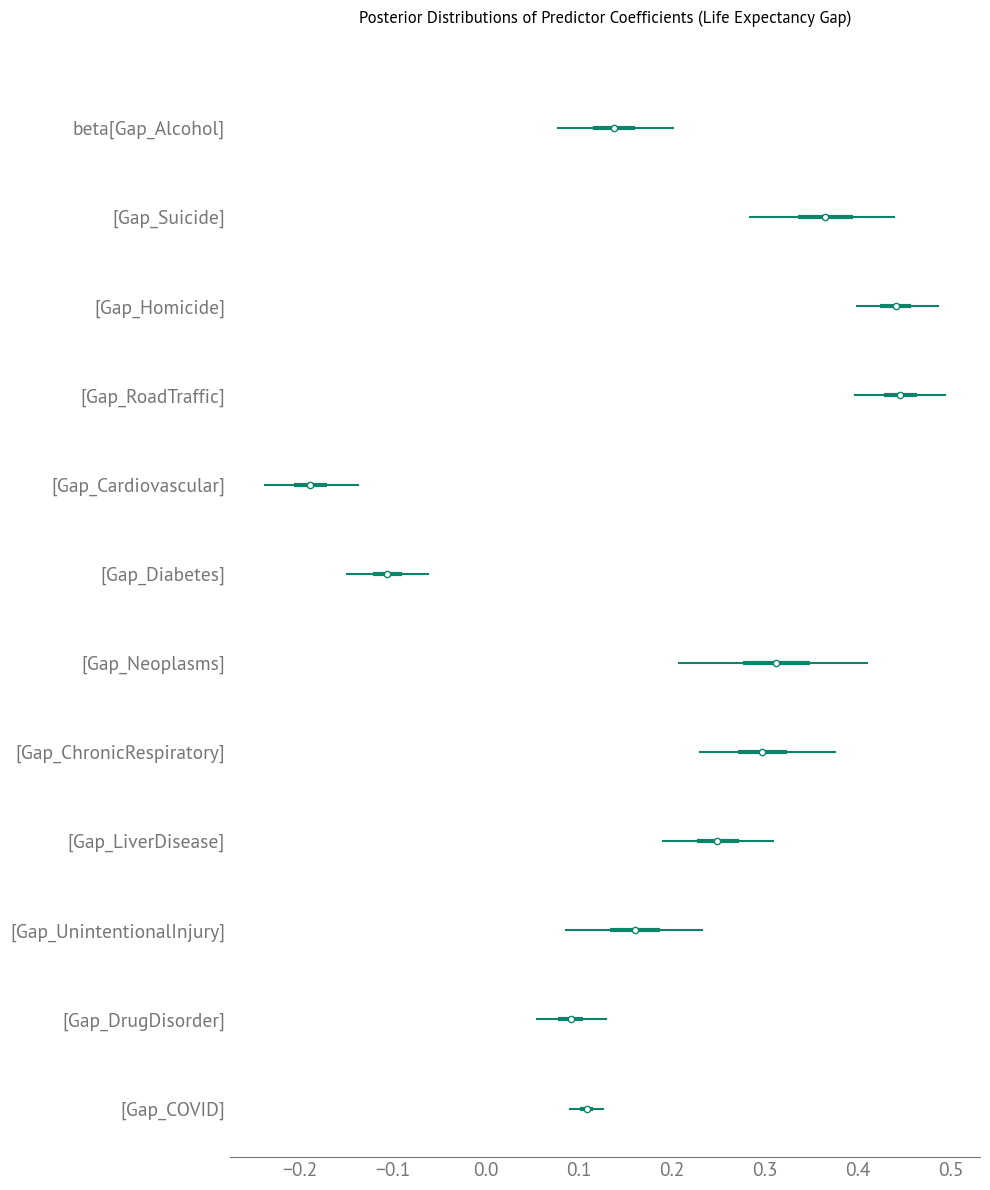

In [21]:
# Plot posterior distributions of beta coefficients (Life Expectancy)
az.plot_forest(trace_le, var_names=["beta"], combined=True, figsize=(10, 12))
plt.title("Posterior Distributions of Predictor Coefficients (Life Expectancy Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('../output/figs/posterior_forest_beta_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Extract posterior means and credible intervals for alpha coefficients (country intercepts, Life Expectancy)
alpha_summary_le = az.summary(trace_le, var_names=["alpha"])
alpha_summary_le.index = data_le["meta"]["countries"]
alpha_summary_le

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
AUS,-0.205,0.071,-0.327,-0.061,0.001,0.001,4238.0,3368.0,1.0
AUT,-0.437,0.080,-0.580,-0.280,0.001,0.001,3482.0,3321.0,1.0
BEL,-0.837,0.090,-1.009,-0.674,0.001,0.001,4188.0,3250.0,1.0
CAN,0.104,0.082,-0.042,0.268,0.001,0.001,3169.0,2945.0,1.0
CHE,-0.263,0.066,-0.388,-0.140,0.001,0.001,4041.0,3578.0,1.0
CHL,-0.469,0.093,-0.651,-0.304,0.002,0.001,3259.0,3552.0,1.0
COL,-0.322,0.170,-0.641,-0.010,0.003,0.003,2795.0,2790.0,1.0
CRI,-0.352,0.112,-0.568,-0.152,0.002,0.002,2662.0,2950.0,1.0
CZE,0.017,0.066,-0.106,0.141,0.001,0.001,3769.0,3152.0,1.0
DEU,-0.346,0.067,-0.465,-0.215,0.001,0.001,4831.0,3215.0,1.0


In [23]:
# Write alpha coefficients table to HTML
alpha_summary_le_formatted = alpha_summary_le.reset_index().rename(columns={'index': 'Country'})
write_html_table(alpha_summary_le_formatted, get_output_filename('../output/tables/alpha_coefficients_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

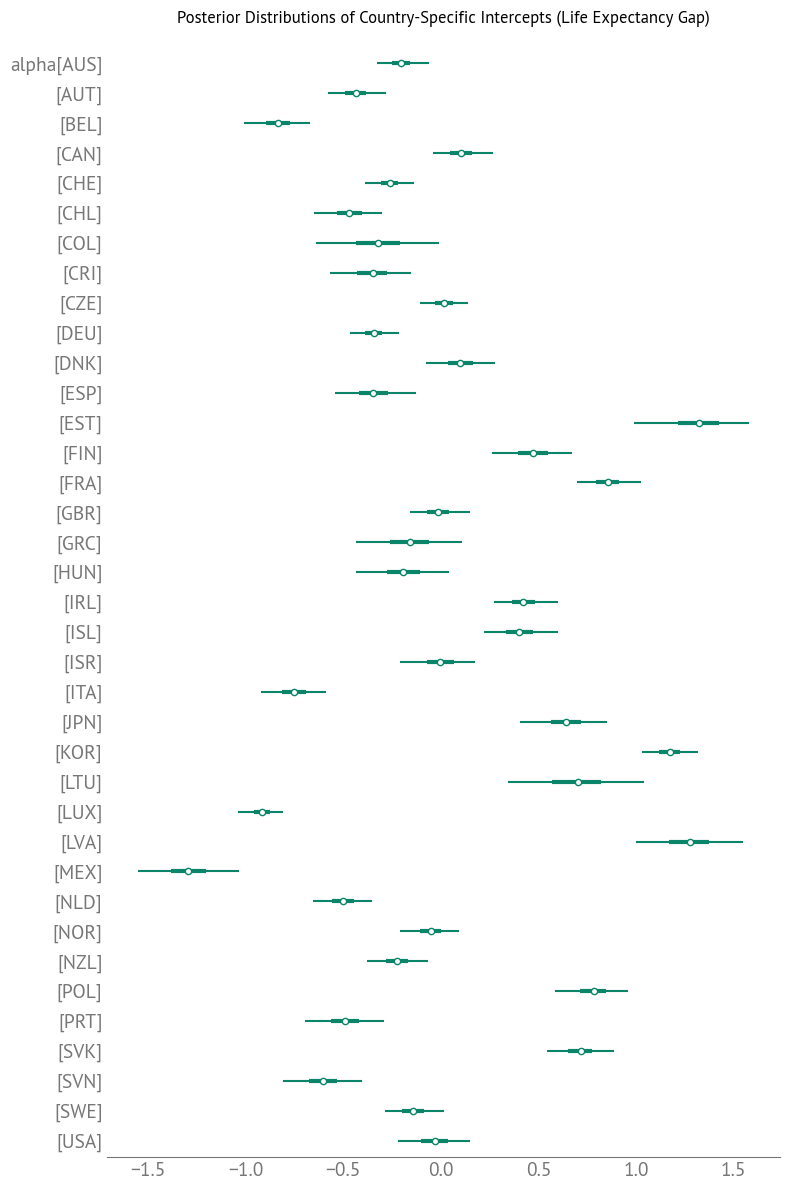

In [24]:
# Plot posterior distributions of country-specific intercepts (alpha) (Life Expectancy)
az.plot_forest(trace_le, var_names=["alpha"], combined=True, figsize=(8, 12))
plt.title("Posterior Distributions of Country-Specific Intercepts (Life Expectancy Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('../output/figs/posterior_forest_alpha_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

### Correlations

In [25]:
# Extract posterior samples for beta coefficients (if not already done)
beta_extracted_le = az.extract(trace_le)
beta_samples_df_le = pd.DataFrame(
    beta_extracted_le['beta'].T,
    columns=data_le["meta"]["predictors"]
)

# Compute correlation matrix for beta coefficients
beta_corr_le = beta_samples_df_le.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
beta_corr_triu = np.triu(beta_corr_le.values, k=1)
beta_corr_long = []
for i in range(len(beta_corr_le.index)):
    for j in range(i + 1, len(beta_corr_le.columns)):
        if not np.isnan(beta_corr_triu[i, j]):
            beta_corr_long.append({
                'Predictor1': beta_corr_le.index[i],
                'Predictor2': beta_corr_le.columns[j],
                'Correlation': beta_corr_triu[i, j]
            })

beta_corr_df_le = pd.DataFrame(beta_corr_long)
beta_corr_df_le['Abs_Correlation'] = beta_corr_df_le['Correlation'].abs()
beta_corr_top10_le = beta_corr_df_le.nlargest(10, 'Abs_Correlation')[
    ['Predictor1', 'Predictor2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among beta coefficients (Life Expectancy):")
beta_corr_top10_le

Top 10 correlations among beta coefficients (Life Expectancy):


,Predictor1,Predictor2,Correlation
51,Gap_Neoplasms,Gap_ChronicRespiratory,-0.436855
46,Gap_Diabetes,Gap_ChronicRespiratory,0.418843
18,Gap_Suicide,Gap_UnintentionalInjury,-0.383683
12,Gap_Suicide,Gap_RoadTraffic,-0.347568
33,Gap_RoadTraffic,Gap_ChronicRespiratory,-0.346002
38,Gap_Cardiovascular,Gap_Diabetes,-0.312576
42,Gap_Cardiovascular,Gap_UnintentionalInjury,-0.306494
32,Gap_RoadTraffic,Gap_Neoplasms,0.288804
8,Gap_Alcohol,Gap_UnintentionalInjury,-0.270640
35,Gap_RoadTraffic,Gap_UnintentionalInjury,-0.243537


In [26]:
# Write beta correlations table to HTML
write_html_table(beta_corr_top10_le, get_output_filename('../output/tables/beta_correlations_top10_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [27]:
# Extract posterior samples for alpha coefficients (country intercepts)
alpha_extracted_le = az.extract(trace_le)
alpha_samples_df_le = pd.DataFrame(
    alpha_extracted_le['alpha'].T,
    columns=data_le["meta"]["countries"]
)

# Compute correlation matrix for alpha coefficients
alpha_corr_le = alpha_samples_df_le.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
alpha_corr_triu = np.triu(alpha_corr_le.values, k=1)
alpha_corr_long = []
for i in range(len(alpha_corr_le.index)):
    for j in range(i + 1, len(alpha_corr_le.columns)):
        if not np.isnan(alpha_corr_triu[i, j]):
            alpha_corr_long.append({
                'Country1': alpha_corr_le.index[i],
                'Country2': alpha_corr_le.columns[j],
                'Correlation': alpha_corr_triu[i, j]
            })

alpha_corr_df_le = pd.DataFrame(alpha_corr_long)
alpha_corr_df_le['Abs_Correlation'] = alpha_corr_df_le['Correlation'].abs()
alpha_corr_top10_le = alpha_corr_df_le.nlargest(10, 'Abs_Correlation')[
    ['Country1', 'Country2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among alpha coefficients (country intercepts, Life Expectancy):")
alpha_corr_top10_le

Top 10 correlations among alpha coefficients (country intercepts, Life Expectancy):


,Country1,Country2,Correlation
379,EST,LVA,0.766648
392,FIN,GRC,-0.692955
589,LTU,LVA,0.690681
377,EST,LTU,0.673959
247,CRI,LTU,-0.665049
191,CHL,MEX,0.646959
201,COL,CRI,0.641472
471,GRC,PRT,0.638509
533,ISR,LTU,-0.627110
350,ESP,ITA,0.619386


In [28]:
# Write alpha correlations table to HTML
write_html_table(alpha_corr_top10_le, get_output_filename('../output/tables/alpha_correlations_top10_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

## Model Evaluation: Posterior Predictive Checks, WAIC, and LOO-CV

### Helper Functions for Model Evaluation

In [29]:
def generate_posterior_predictive_samples(model, trace):
    """
    Generate posterior predictive samples from a PyMC model.
    
    Parameters
    ----------
    model : pymc.Model
        PyMC model object
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
        
    Returns
    -------
    ppc : arviz.InferenceData
        InferenceData object with posterior predictive samples
    """
    with model:
        ppc = pm.sample_posterior_predictive(trace, extend_inferencedata=True)
    return ppc


def extract_ppc_data(ppc, y_obs):
    """
    Extract and reshape posterior predictive data.
    
    Parameters
    ----------
    ppc : arviz.InferenceData
        InferenceData object with posterior predictive samples
    y_obs : array-like
        Observed data
        
    Returns
    -------
    y_ppc_flat : ndarray
        Flattened posterior predictive samples (chains * draws, obs)
    """
    y_ppc = ppc.posterior_predictive["y_obs"].values
    # Reshape: (chains, draws, obs) -> (chains * draws, obs)
    y_ppc_flat = y_ppc.reshape(-1, y_ppc.shape[-1])
    return y_ppc_flat


def plot_ppc_distributions(ppc, y_obs, y_ppc_flat, title, xlabel, output_filename):
    """
    Plot posterior predictive check: distribution comparison and Q-Q plot.
    
    Parameters
    ----------
    ppc : arviz.InferenceData
        InferenceData object with posterior predictive samples
    y_obs : array-like
        Observed data
    y_ppc_flat : ndarray
        Flattened posterior predictive samples
    title : str
        Title prefix for plots
    xlabel : str
        X-axis label
    output_filename : str
        Filename to save the figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Overlay of observed vs posterior predictive distributions
    ax = axes[0]
    az.plot_ppc(ppc, ax=ax, num_pp_samples=100)
    ax.set_title(f"Posterior Predictive Check: Distribution Comparison ({title})")
    ax.set_xlabel(xlabel)
    
    # Plot 2: Q-Q plot comparing observed vs posterior predictive quantiles
    ax = axes[1]
    # Compute quantiles for observed data and all posterior predictive samples (pooled)
    qs = np.linspace(0, 100, 100)
    obs_quantiles = np.percentile(y_obs, qs)
    # Pool all posterior predictive draws and compute quantiles
    ppc_quantiles = np.percentile(y_ppc_flat.ravel(), qs)
    ax.scatter(obs_quantiles, ppc_quantiles, alpha=0.6, color='C3')
    # Add diagonal line
    min_val = min(obs_quantiles.min(), ppc_quantiles.min())
    max_val = max(obs_quantiles.max(), ppc_quantiles.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect fit')
    ax.set_xlabel("Observed Quantiles")
    ax.set_ylabel("Posterior Predictive Quantiles")
    ax.set_title(f"Q-Q Plot: Observed vs Posterior Predictive ({title})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()


def plot_ppc_test_statistics(y_obs, y_ppc_flat, output_filename):
    """
    Plot posterior predictive check: test statistics comparison.
    
    Parameters
    ----------
    y_obs : array-like
        Observed data
    y_ppc_flat : ndarray
        Flattened posterior predictive samples
    output_filename : str
        Filename to save the figure
    """
    # Compute test statistics
    obs_mean = y_obs.mean()
    ppc_mean = y_ppc_flat.mean(axis=1)
    
    obs_std = y_obs.std()
    ppc_std = y_ppc_flat.std(axis=1)
    
    obs_min = y_obs.min()
    ppc_min = y_ppc_flat.min(axis=1)
    
    obs_max = y_obs.max()
    ppc_max = y_ppc_flat.max(axis=1)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    test_stats = [
        ("Mean", obs_mean, ppc_mean),
        ("Standard Deviation", obs_std, ppc_std),
        ("Minimum", obs_min, ppc_min),
        ("Maximum", obs_max, ppc_max),
    ]
    
    for i, (name, obs_val, ppc_vals) in enumerate(test_stats):
        ax = axes[i]
        ax.hist(ppc_vals, bins=50, alpha=0.7, color='C0', label='Posterior Predictive')
        ax.axvline(obs_val, color='C3', linewidth=2, linestyle='--', 
                   label=f'Observed: {obs_val:.3f}')
        # Compute p-value (proportion of ppc values more extreme than observed)
        p_value = np.mean(np.abs(ppc_vals - ppc_vals.mean()) >= np.abs(obs_val - ppc_vals.mean()))
        ax.set_xlabel(name)
        ax.set_ylabel('Density')
        ax.set_title(f'{name} Test Statistic\n(p-value: {p_value:.3f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()


def compute_model_metrics(model, trace, model_name):
    """
    Compute WAIC and LOO-CV metrics for a model.
    
    Parameters
    ----------
    model : pymc.Model
        PyMC model object
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
    model_name : str
        Name of the model (for printing)
        
    Returns
    -------
    waic : arviz.Waic
        WAIC object
    loo : arviz.Loo
        LOO object
    """
    with model:
        waic = az.waic(trace, pointwise=True)  # elpd_waic
        loo = az.loo(trace, pointwise=True)    # elpd_loo
    
    waic_elpd = waic.elpd_waic
    loo_elpd = loo.elpd_loo
    
    print(f"{model_name} - Model Comparison Metrics:")
    print(f"WAIC (ELPD): {waic_elpd:.2f} (SE: {waic.se:.2f})")
    print(f"LOO (ELPD):  {loo_elpd:.2f} (SE: {loo.se:.2f})")
    print(f"\nEffective number of parameters:")
    print(f"  WAIC p_waic: {waic.p_waic:.2f}")
    print(f"  LOO  p_loo:  {loo.p_loo:.2f}")
    
    return waic, loo


def plot_waic_loo(waic, loo, model_name, output_filename):
    """
    Plot WAIC and LOO pointwise contributions.
    
    Parameters
    ----------
    waic : arviz.Waic
        WAIC object
    loo : arviz.Loo
        LOO object
    model_name : str
        Name of the model (for plot titles)
    output_filename : str
        Filename to save the figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # WAIC pointwise
    ax = axes[0]
    ax.scatter(range(len(waic.waic_i)), waic.waic_i, alpha=0.6, color='C3')
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("Pointwise WAIC Contribution")
    ax.set_title(f"Pointwise WAIC Contributions ({model_name})")
    ax.grid(True, alpha=0.3)
    
    # LOO pointwise
    ax = axes[1]
    ax.scatter(range(len(loo.loo_i)), loo.loo_i, alpha=0.6, color='C0')
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("Pointwise LOO Contribution")
    ax.set_title(f"Pointwise LOO Contributions ({model_name})")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()


def check_pareto_k(loo, data, model_name, threshold=0.7):
    """
    Check Pareto k values to identify problematic observations.
    
    Pareto k > 0.7 indicates potentially problematic observations where
    LOO-CV may be unreliable.
    
    Parameters
    ----------
    loo : arviz.Loo
        LOO object
    data : dict
        Data dictionary from prepare_panel_data
    model_name : str
        Name of the model (for printing)
    threshold : float
        Threshold for problematic observations (default: 0.7)
        
    Returns
    -------
    problematic : pandas.DataFrame
        DataFrame with observations having Pareto k > threshold
    """
    pareto_k = loo.pareto_k
    
    # Find problematic observations
    problematic_mask = pareto_k > threshold
    n_problematic = problematic_mask.sum()
    
    print(f"\nPareto k diagnostics ({model_name}):")
    print(f"  Observations with k > {threshold}: {n_problematic} ({100*n_problematic/len(pareto_k):.1f}%)")
    print(f"  Maximum Pareto k: {pareto_k.max():.3f}")
    print(f"  Mean Pareto k: {pareto_k.mean():.3f}")
    print(f"  Median Pareto k: {np.median(pareto_k):.3f}")
    
    if n_problematic > 0:
        problematic_df = pd.DataFrame({
            'Observation': np.where(problematic_mask)[0],
            'Pareto_k': pareto_k[problematic_mask],
            'Country': [data["meta"]["countries"][data["country_idx"][i]] 
                       for i in np.where(problematic_mask)[0]],
            'Year': [data["meta"]["years"][data["year_idx"][i]] 
                    for i in np.where(problematic_mask)[0]]
        })
        problematic_df = problematic_df.sort_values('Pareto_k', ascending=False)
        print(f"\n  Top problematic observations (k > {threshold}):")
        print(problematic_df.head(10).to_string(index=False))
        return problematic_df
    else:
        print(f"  No observations exceed threshold (k > {threshold})")
        return pd.DataFrame()


def identify_influential_observations(loo, data, model_name, output_filename, top_n=10):
    """
    Identify observations with high influence (high |LOO contribution|).
    
    Parameters
    ----------
    loo : arviz.Loo
        LOO object
    data : dict
        Data dictionary from prepare_panel_data
    model_name : str
        Name of the model (for printing)
    output_filename : str
        Filename to save HTML table
    top_n : int
        Number of top influential observations to return (default: 10)
        
    Returns
    -------
    top_influential : pandas.DataFrame
        DataFrame with top influential observations
    """
    loo_i_df = pd.DataFrame({
        'Observation': range(len(loo.loo_i)),
        'LOO_i': loo.loo_i,
        'Abs_LOO_i': np.abs(loo.loo_i),
        'Pareto_k': loo.pareto_k
    })
    
    # Get top N most influential observations
    top_influential = loo_i_df.nlargest(top_n, 'Abs_LOO_i')
    print(f"Top {top_n} most influential observations ({model_name}):")
    print(top_influential)
    
    # Add country and year information
    top_influential['Country'] = [data["meta"]["countries"][data["country_idx"][i]] 
                                  for i in top_influential['Observation']]
    top_influential['Year'] = [data["meta"]["years"][data["year_idx"][i]] 
                              for i in top_influential['Observation']]
    
    # Write to HTML table (update filename with suffix)
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    write_html_table(
        top_influential[['Country', 'Year', 'LOO_i', 'Pareto_k']].rename(
            columns={'LOO_i': 'LOO Contribution', 'Pareto_k': 'Pareto k'}
        ),
        output_filename_suffixed
    )
    
    return top_influential[['Observation', 'Country', 'Year', 'LOO_i', 'Abs_LOO_i', 'Pareto_k']]

### Life Expectancy Gap Model Evaluation

#### Posterior Predictive Checks

In [30]:
# Generate posterior predictive samples for Life Expectancy model
ppc_le = generate_posterior_predictive_samples(model_le, trace_le)

Sampling: [y_obs]


Output()

In [31]:
# Extract observed and posterior predictive data
y_obs_le = data_le["y_centered"]
y_ppc_le_flat = extract_ppc_data(ppc_le, y_obs_le)

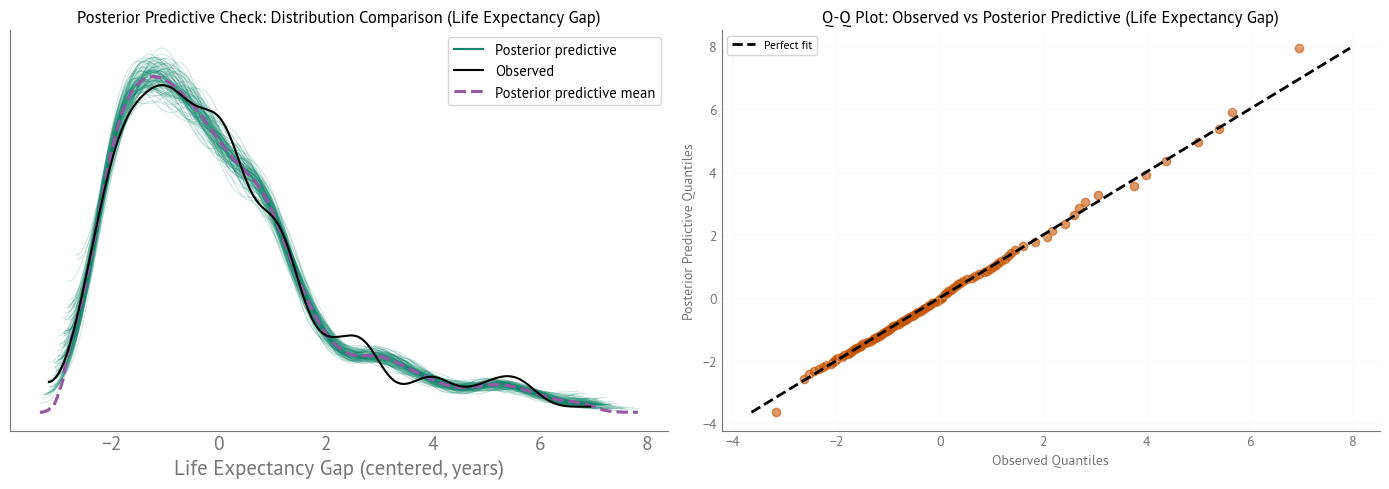

In [32]:
# Plot posterior predictive check: distribution comparison and Q-Q plot
plot_ppc_distributions(
    ppc_le, y_obs_le, y_ppc_le_flat,
    title="Life Expectancy Gap",
    xlabel="Life Expectancy Gap (centered, years)",
    output_filename='../output/figs/ppc_le.png'
)

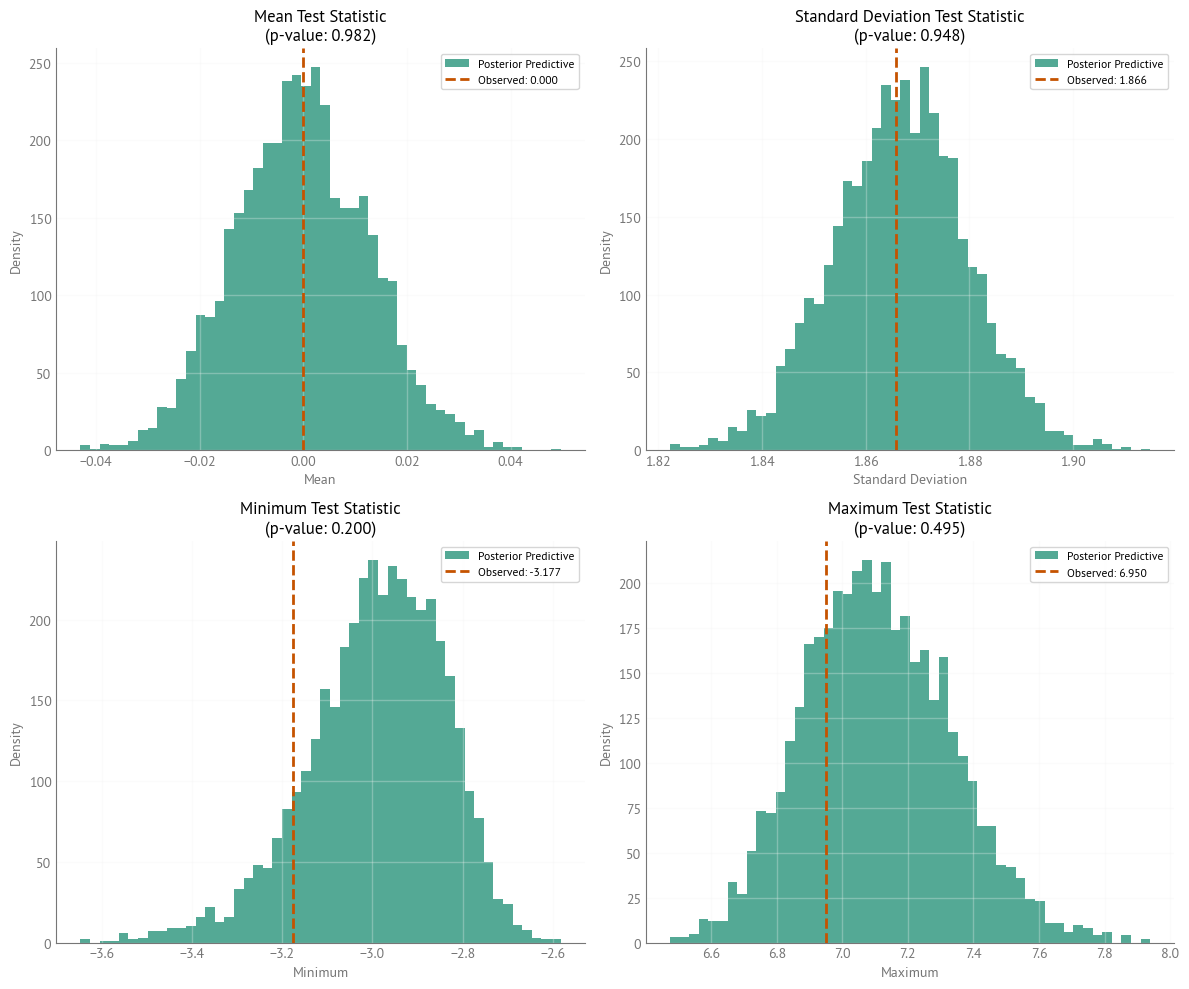

In [33]:
# Posterior predictive check: test statistics
plot_ppc_test_statistics(
    y_obs_le, y_ppc_le_flat,
    output_filename='../output/figs/ppc_test_stats_le.png'
)

#### WAIC and LOO-CV

In [34]:
# Compute WAIC and LOO-CV for Life Expectancy model
waic_le, loo_le = compute_model_metrics(model_le, trace_le, "Life Expectancy Gap Model")

/home/downey/miniconda3/envs/LifeExpectancy/lib/python3.11/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Life Expectancy Gap Model - Model Comparison Metrics:
WAIC (ELPD): -143.48 (SE: 32.60)
LOO (ELPD):  -143.85 (SE: 32.60)

Effective number of parameters:
  WAIC p_waic: 54.86
  LOO  p_loo:  55.23


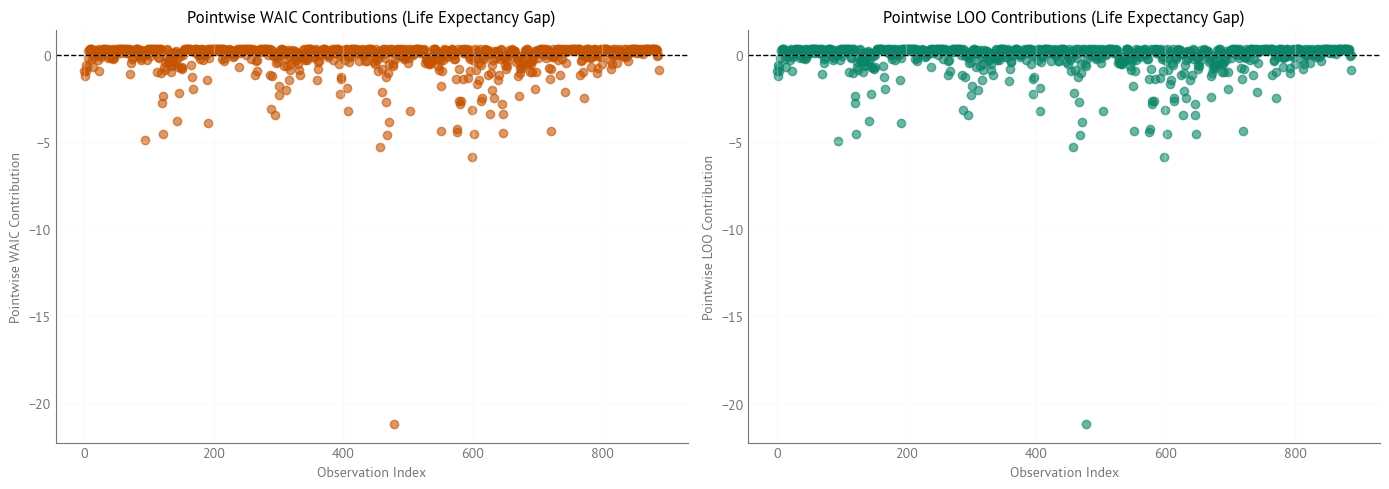

In [35]:
# Plot WAIC and LOO pointwise contributions
plot_waic_loo(
    waic_le, loo_le,
    model_name="Life Expectancy Gap",
    output_filename='../output/figs/waic_loo_le.png'
)

In [36]:
# Log model comparison metrics
log_and_print("\n" + "="*80)
log_and_print("MODEL COMPARISON METRICS")
log_and_print("="*80)
log_and_print("Life Expectancy Gap Model:")
log_and_print(f"  WAIC (ELPD): {waic_le.elpd_waic:.2f} (SE: {waic_le.se:.2f})")
log_and_print(f"  LOO (ELPD):  {loo_le.elpd_loo:.2f} (SE: {loo_le.se:.2f})")
log_and_print(f"  p_waic: {waic_le.p_waic:.2f}, p_loo: {loo_le.p_loo:.2f}")
log_and_print("="*80)


MODEL COMPARISON METRICS
Life Expectancy Gap Model:
  WAIC (ELPD): -143.48 (SE: 32.60)
  LOO (ELPD):  -143.85 (SE: 32.60)
  p_waic: 54.86, p_loo: 55.23


In [37]:
# Check Pareto k values for problematic observations
problematic_le = check_pareto_k(loo_le, data_le, model_name="Life Expectancy Gap")

# Log Pareto k diagnostics
pareto_k = loo_le.pareto_k
n_problematic = (pareto_k > 0.7).sum()
log_and_print("\nPareto k diagnostics:")
log_and_print(f"  Max k: {pareto_k.max():.3f}")
log_and_print(f"  Mean k: {pareto_k.mean():.3f}")
log_and_print(f"  k > 0.7: {n_problematic} ({100*n_problematic/len(pareto_k):.1f}%)")


Pareto k diagnostics (Life Expectancy Gap):
  Observations with k > 0.7: <xarray.DataArray 'pareto_shape' ()> Size: 8B
array(0) (0.0%)
  Maximum Pareto k: 0.602
  Mean Pareto k: 0.102
  Median Pareto k: 0.101
  No observations exceed threshold (k > 0.7)

Pareto k diagnostics:
  Max k: 0.602
  Mean k: 0.102
  k > 0.7: <xarray.DataArray 'pareto_shape' ()> Size: 8B
array(0) (0.0%)


In [38]:
# Identify observations with high influence (high |LOO contribution|)
top_influential_le = identify_influential_observations(
    loo_le, data_le,
    model_name="Life Expectancy Gap",
    output_filename='../output/tables/influential_observations_le.html'
)
top_influential_le

Top 10 most influential observations (Life Expectancy Gap):
     Observation      LOO_i  Abs_LOO_i  Pareto_k
478          478 -21.165264  21.165264  0.585825
598          598  -5.871134   5.871134  0.471136
457          457  -5.299143   5.299143  0.214921
94            94  -4.934204   4.934204  0.601607
468          468  -4.598131   4.598131  0.203259
122          122  -4.568928   4.568928  0.170863
602          602  -4.562273   4.562273  0.200057
647          647  -4.519740   4.519740  0.242433
575          575  -4.449726   4.449726  0.154635
720          720  -4.398031   4.398031  0.197833


,Observation,Country,Year,LOO_i,Abs_LOO_i,Pareto_k
478,478,ISL,2022,-21.165264,21.165264,0.585825
598,598,LTU,2022,-5.871134,5.871134,0.471136
457,457,ISL,2001,-5.299143,5.299143,0.214921
94,94,CAN,2022,-4.934204,4.934204,0.601607
468,468,ISL,2012,-4.598131,4.598131,0.203259
122,122,CHL,2002,-4.568928,4.568928,0.170863
602,602,LUX,2002,-4.562273,4.562273,0.200057
647,647,LVA,2023,-4.519740,4.519740,0.242433
575,575,KOR,2023,-4.449726,4.449726,0.154635
720,720,NZL,2000,-4.398031,4.398031,0.197833


### Model Comparison Summary

In [39]:
# Create summary table for Life Expectancy model
# Both WAIC and LOO are on ELPD scale
model_comparison = pd.DataFrame({
    'Model': ['Life Expectancy Gap'],
    'WAIC (ELPD)': [waic_le.elpd_waic],
    'WAIC_SE': [waic_le.se],
    'LOO (ELPD)': [loo_le.elpd_loo],
    'LOO_SE': [loo_le.se],
    'p_waic': [waic_le.p_waic],
    'p_loo': [loo_le.p_loo],
})

print("Model Summary:")
print(model_comparison.to_string(index=False))

Model Summary:
              Model  WAIC (ELPD)   WAIC_SE  LOO (ELPD)    LOO_SE    p_waic     p_loo
Life Expectancy Gap  -143.479246 32.604237 -143.847232 32.602299 54.863909 55.231895


In [40]:
# Write model comparison table to HTML
write_html_table(model_comparison, get_output_filename('../output/tables/model_comparison_metrics.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

## R² and Residual Analysis

Compute R² (explained variance) and perform residual analysis for comparison with Elastic Net models and diagnostic purposes.

### Helper Functions for R² and Residual Analysis

In [41]:
def compute_predictions_and_residuals(trace, data, include_year_effects=False):
    """
    Compute posterior mean predictions and residuals for all observations.
    
    Parameters
    ----------
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
    data : dict
        Data dictionary with 'X' (standardized), 'y_centered', 'meta', etc.
    include_year_effects : bool
        Whether year effects were included in the model
        
    Returns
    -------
    dict
        Dictionary with predictions, residuals, and metadata
    """
    # Extract posterior samples
    beta_samples = trace.posterior['beta'].values.reshape(-1, len(data['meta']['predictors']))
    alpha_samples = trace.posterior['alpha'].values.reshape(-1, len(data['meta']['countries']))
    
    # Get data
    X_std = data['X']  # Already standardized
    y_centered = data['y_centered']
    y_mean = data['meta']['y_mean']
    y_original = y_centered + y_mean  # Reconstruct original scale
    country_idx = data['country_idx']
    
    # Get year indices if year effects were included
    if include_year_effects:
        year_idx = data['year_idx']
        gamma_samples = trace.posterior['gamma'].values.reshape(-1, len(data['meta']['years']))
    else:
        year_idx = None
        gamma_samples = None
    
    # Compute predictions for each posterior sample
    n_samples = beta_samples.shape[0]
    n_obs = len(y_centered)
    predictions_centered = np.zeros((n_samples, n_obs))
    
    for i in range(n_samples):
        # Get country-specific intercepts
        alpha_i = alpha_samples[i, country_idx]
        
        # Linear predictor: alpha + X @ beta
        mu_centered = alpha_i + np.dot(X_std, beta_samples[i])
        
        # Add year effects if included
        if include_year_effects:
            gamma_i = gamma_samples[i, year_idx]
            mu_centered = mu_centered + gamma_i
        
        predictions_centered[i] = mu_centered
    
    # Convert to original scale
    predictions_original = predictions_centered + y_mean
    
    # Compute posterior mean predictions
    y_pred_mean = np.mean(predictions_original, axis=0)
    
    # Compute residuals (on original scale)
    residuals = y_original - y_pred_mean
    
    # Compute Bayesian R² (correct method for Bayesian models, matching brms)
    # Formula: R² = Var(μ) / (Var(μ) + Var(y - μ))
    # Where for each posterior draw:
    #   Var(μ) = variance of the linear predictor (mu) across observations for that draw
    #   Var(y - μ) = empirical variance of residuals (y - μ) for that draw
    # This uses the empirical residual variance, which captures both model noise (σ²) 
    # and lack-of-fit (systematic error), not just the assumed noise variance.
    # This is the Gelman et al. Bayesian R² used by brms.
    
    # Compute Bayesian R² for each posterior draw (brms-style)
    # Note: brms uses population variance (ddof=0), not sample variance (ddof=1)
    # This matches the standard Bayesian R² formula from Gelman et al.
    # 
    # IMPORTANT: In hierarchical models, there are two types of R²:
    # - Conditional R²: includes random effects (country intercepts) in μ
    # - Marginal R²: uses only fixed effects (population-level), no random intercepts
    #
    # brms's bayes_R2() by default computes CONDITIONAL R² (includes random effects)
    # unless you use re_formula = NA to get marginal R²
    
    # CONDITIONAL R²: μ includes country intercepts (alpha[country_idx])
    r2_cond_samples = np.empty(n_samples)
    
    # MARGINAL R²: μ uses only fixed effects (mu_alpha + X @ beta), no country deviations
    # Extract mu_alpha (grand mean) for each draw
    mu_alpha_samples = trace.posterior['mu_alpha'].values.flatten()
    r2_marg_samples = np.empty(n_samples)
    
    for i in range(n_samples):
        # Conditional: μ includes country intercepts (current implementation)
        mu_cond = predictions_original[i]  # Predictions with country intercepts
        var_mu_cond = np.var(mu_cond, ddof=0)
        resid_cond = y_original - mu_cond
        var_resid_cond = np.var(resid_cond, ddof=0)
        r2_cond_samples[i] = var_mu_cond / (var_mu_cond + var_resid_cond)
        
        # Marginal: μ = mu_alpha + X @ beta (no country intercepts)
        mu_marg = mu_alpha_samples[i] + np.dot(X_std, beta_samples[i])
        # Convert to original scale
        mu_marg_original = mu_marg + y_mean
        var_mu_marg = np.var(mu_marg_original, ddof=0)
        resid_marg = y_original - mu_marg_original
        var_resid_marg = np.var(resid_marg, ddof=0)
        r2_marg_samples[i] = var_mu_marg / (var_mu_marg + var_resid_marg)
    
    # Use conditional R² as the default (matches brms default)
    r2_samples = r2_cond_samples
    r2_mean = np.mean(r2_samples)
    r2_hdi = az.hdi(r2_samples, hdi_prob=0.94)
    
    # Also compute marginal R² statistics
    r2_marg_mean = np.mean(r2_marg_samples)
    r2_marg_hdi = az.hdi(r2_marg_samples, hdi_prob=0.94)
    
    return {
        'y_pred_mean': y_pred_mean,
        'y_pred_samples': predictions_original,
        'residuals': residuals,
        'r2_mean': r2_mean,  # Conditional R² (default, matches brms)
        'r2_samples': r2_samples,  # Conditional R² samples
        'r2_hdi': r2_hdi,  # Conditional R² HDI
        'r2_marg_mean': r2_marg_mean,  # Marginal R² (fixed effects only)
        'r2_marg_samples': r2_marg_samples,  # Marginal R² samples
        'r2_marg_hdi': r2_marg_hdi,  # Marginal R² HDI
        'y_original': y_original,
        'y_mean': y_mean,
    }


def plot_residuals_vs_predicted(y_pred, residuals, title, output_filename):
    """
    Plot residuals vs. predicted values.
    
    Parameters
    ----------
    y_pred : array-like
        Predicted values
    residuals : array-like
        Residuals
    title : str
        Plot title
    output_filename : str
        Output filename for saved figure
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(y_pred, residuals, color='C3', alpha=0.6)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted Value (years)', fontsize=12)
    ax.set_ylabel('Residual (years)', fontsize=12)
    ax.set_title(f'Residuals vs. Predicted Values: {title}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()


def plot_residuals_vs_country(residuals, country_idx, countries, years_data, title, output_filename):
    """
    Plot residuals by country for 2019 only.
    
    Parameters
    ----------
    residuals : array-like
        Residuals
    country_idx : array-like
        Country indices for each observation
    countries : array-like
        List of country codes
    years_data : array-like
        Year for each observation
    title : str
        Plot title
    output_filename : str
        Output filename for saved figure
    """
    # Create DataFrame for easier plotting
    df = pd.DataFrame({
        'Country': [countries[i] for i in country_idx],
        'Residual': residuals,
        'Year': years_data
    })
    
    # Filter to 2019 only
    df_2019 = df[df['Year'] == 2019].copy()
    
    # Sort by residual value
    df_2019_sorted = df_2019.sort_values('Residual')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    y_pos = np.arange(len(df_2019_sorted))
    colors = ['C3' if x < 0 else 'C0' for x in df_2019_sorted['Residual'].values]
    ax.barh(y_pos, df_2019_sorted['Residual'].values, color=colors, alpha=0.7)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_2019_sorted['Country'].values)
    ax.set_xlabel('Residual (years)', fontsize=12)
    ax.set_title(f'Residuals by Country (2019): {title}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()


def plot_residuals_vs_year(residuals, years_data, title, output_filename):
    """
    Plot residuals vs. year.
    
    Parameters
    ----------
    residuals : array-like
        Residuals
    years_data : array-like
        Year for each observation
    title : str
        Plot title
    output_filename : str
        Output filename for saved figure
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(years_data, residuals, color='C3', alpha=0.6)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Residual (years)', fontsize=12)
    ax.set_title(f'Residuals vs. Year: {title}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()


def plot_residual_histogram(residuals, title, output_filename):
    """
    Plot histogram of residuals.
    
    Parameters
    ----------
    residuals : array-like
        Residuals
    title : str
        Plot title
    output_filename : str
        Output filename for saved figure
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(residuals, bins=20, color='C3', edgecolor='white', alpha=0.7)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=np.mean(residuals), color='black', linestyle='-', linewidth=2, label=f'Mean: {np.mean(residuals):.3f}')
    ax.set_xlabel('Residual (years)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'Distribution of Residuals: {title}', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

### Life Expectancy Gap Model: R² and Residuals

In [42]:
# Compute predictions and residuals for Life Expectancy model
# NOTE: If R² is still showing ~0.98, restart the kernel to ensure the updated 
# compute_predictions_and_residuals() function is used (not a cached version)
results_le = compute_predictions_and_residuals(
    trace_le, data_le, include_year_effects=INCLUDE_YEAR_EFFECTS
)

# Print and log R² summary
log_and_print("\n" + "="*80)
log_and_print("R² AND RESIDUAL ANALYSIS")
log_and_print("="*80)
log_and_print("CONDITIONAL R² (includes country random effects):")
log_and_print(f"  R² (mean): {results_le['r2_mean']:.4f}")
log_and_print(f"  R² (94% HDI): [{results_le['r2_hdi'][0]:.4f}, {results_le['r2_hdi'][1]:.4f}]")
log_and_print("\nMARGINAL R² (fixed effects only, no country intercepts):")
log_and_print(f"  R² (mean): {results_le['r2_marg_mean']:.4f}")
log_and_print(f"  R² (94% HDI): [{results_le['r2_marg_hdi'][0]:.4f}, {results_le['r2_marg_hdi'][1]:.4f}]")
log_and_print("\nNote: brms bayes_R2() by default computes CONDITIONAL R² (includes random effects).")
log_and_print("      Use re_formula = NA in brms to get MARGINAL R² for comparison.")
log_and_print("\nResidual Statistics:")
log_and_print(f"  Mean: {np.mean(results_le['residuals']):.4f} years")
log_and_print(f"  Std: {np.std(results_le['residuals']):.4f} years")
log_and_print(f"  Min: {np.min(results_le['residuals']):.4f} years")
log_and_print(f"  Max: {np.max(results_le['residuals']):.4f} years")
log_and_print(f"  MAE: {np.mean(np.abs(results_le['residuals'])):.4f} years")
log_and_print("="*80)

# Get year data for each observation (needed for residual plots)
years_data_le = np.array([data_le['meta']['years'][i] for i in data_le['year_idx']])


R² AND RESIDUAL ANALYSIS
CONDITIONAL R² (includes country random effects):
  R² (mean): 0.9783
  R² (94% HDI): [0.9777, 0.9789]

MARGINAL R² (fixed effects only, no country intercepts):
  R² (mean): 0.8450
  R² (94% HDI): [0.8124, 0.8793]

Note: brms bayes_R2() by default computes CONDITIONAL R² (includes random effects).
      Use re_formula = NA in brms to get MARGINAL R² for comparison.

Residual Statistics:
  Mean: 0.0002 years
  Std: 0.2674 years
  Min: -0.8456 years
  Max: 1.7255 years
  MAE: 0.2001 years


In [43]:
# Diagnostic: Compare conditional vs marginal R²
# The key insight: In hierarchical models, R² can be computed two ways:
# - CONDITIONAL: includes random effects (country intercepts) → typically higher
# - MARGINAL: fixed effects only → typically lower, more conservative
#
# brms's bayes_R2() by default computes CONDITIONAL R² (includes random effects)
# Use re_formula = NA to get MARGINAL R²
log_and_print("\n" + "="*80)
log_and_print("R² DIAGNOSTIC: CONDITIONAL vs MARGINAL")
log_and_print("="*80)
log_and_print("CONDITIONAL R² (includes country random effects):")
log_and_print(f"  PyMC: {results_le['r2_mean']:.4f} (94% HDI: [{results_le['r2_hdi'][0]:.4f}, {results_le['r2_hdi'][1]:.4f}])")
log_and_print(f"  brms: 0.734 (95% CI: 0.074 - 0.979) [from log]")
log_and_print("\nMARGINAL R² (fixed effects only, no country intercepts):")
log_and_print(f"  PyMC: {results_le['r2_marg_mean']:.4f} (94% HDI: [{results_le['r2_marg_hdi'][0]:.4f}, {results_le['r2_marg_hdi'][1]:.4f}])")
log_and_print(f"  brms: [run notebook to get marginal R²]")
log_and_print("\n" + "="*80)
log_and_print("INTERPRETATION:")
log_and_print("  - If brms conditional R² (0.734) matches PyMC MARGINAL R², then brms")
log_and_print("    is computing marginal R² despite using default bayes_R2().")
log_and_print("  - If brms conditional R² matches PyMC CONDITIONAL R² (~0.98), then")
log_and_print("    both are computing conditional R² correctly.")
log_and_print("  - The marginal R² is typically lower and more conservative, as it")
log_and_print("    doesn't include the variance explained by country-level effects.")
log_and_print("="*80)


R² DIAGNOSTIC: CONDITIONAL vs MARGINAL
CONDITIONAL R² (includes country random effects):
  PyMC: 0.9783 (94% HDI: [0.9777, 0.9789])
  brms: 0.734 (95% CI: 0.074 - 0.979) [from log]

MARGINAL R² (fixed effects only, no country intercepts):
  PyMC: 0.8450 (94% HDI: [0.8124, 0.8793])
  brms: [run notebook to get marginal R²]

INTERPRETATION:
  - If brms conditional R² (0.734) matches PyMC MARGINAL R², then brms
    is computing marginal R² despite using default bayes_R2().
  - If brms conditional R² matches PyMC CONDITIONAL R² (~0.98), then
    both are computing conditional R² correctly.
  - The marginal R² is typically lower and more conservative, as it
    doesn't include the variance explained by country-level effects.


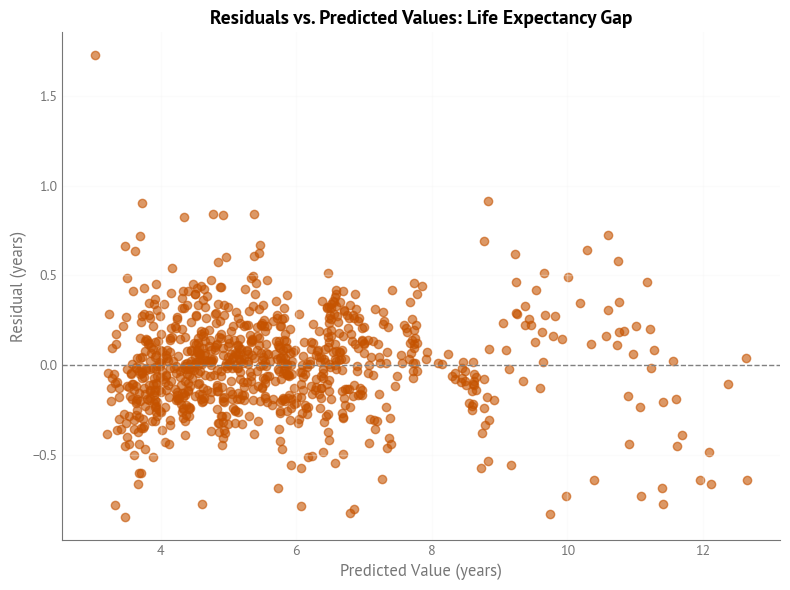

In [44]:
# Residuals vs. Predicted Values
plot_residuals_vs_predicted(
    results_le['y_pred_mean'],
    results_le['residuals'],
    "Life Expectancy Gap",
    get_output_filename('../output/figs/residuals_vs_predicted_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

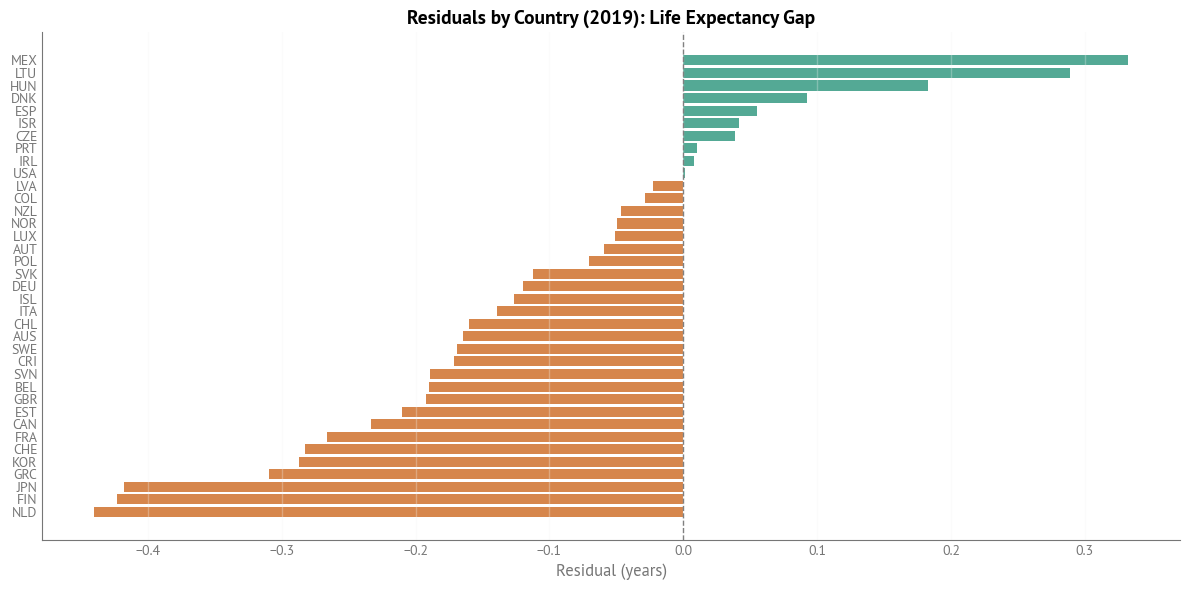

In [45]:
# Residuals vs. Country (2019 only)
plot_residuals_vs_country(
    results_le['residuals'],
    data_le['country_idx'],
    data_le['meta']['countries'],
    years_data_le,
    "Life Expectancy Gap",
    get_output_filename('../output/figs/residuals_vs_country_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

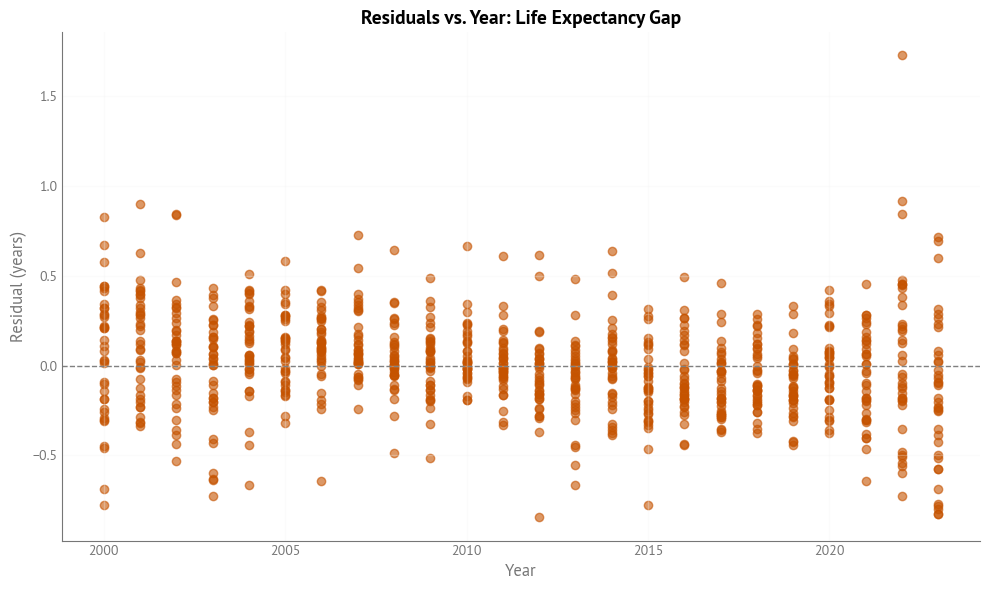

In [46]:
# Residuals vs. Year
plot_residuals_vs_year(
    results_le['residuals'],
    years_data_le,
    "Life Expectancy Gap",
    get_output_filename('../output/figs/residuals_vs_year_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

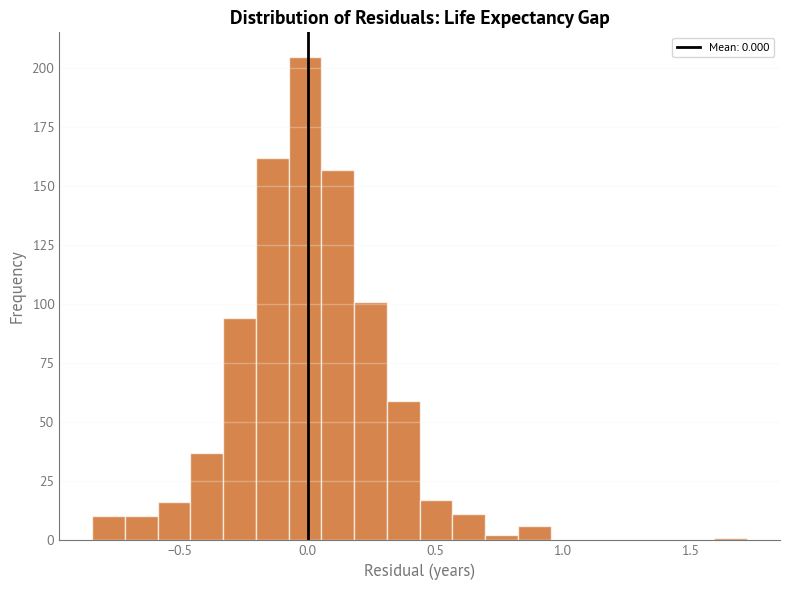

In [47]:
# Residual Histogram
plot_residual_histogram(
    results_le['residuals'],
    "Life Expectancy Gap",
    get_output_filename('../output/figs/residuals_histogram_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

In [48]:
# Create residual summary table for Life Expectancy
residual_summary_le = pd.DataFrame({
    'Statistic': ['Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max', 'MAE'],
    'Value (years)': [
        np.mean(results_le['residuals']),
        np.std(results_le['residuals']),
        np.min(results_le['residuals']),
        np.percentile(results_le['residuals'], 25),
        np.median(results_le['residuals']),
        np.percentile(results_le['residuals'], 75),
        np.max(results_le['residuals']),
        np.mean(np.abs(results_le['residuals']))
    ]
})

residual_summary_le['Value (years)'] = residual_summary_le['Value (years)'].round(4)
residual_summary_le

,Statistic,Value (years)
0,Mean,0.0002
1,Std,0.2674
2,Min,-0.8456
3,25%,-0.1647
4,Median,0.0037
5,75%,0.1462
6,Max,1.7255
7,MAE,0.2001


In [49]:
# Write residual summary to HTML
write_html_table(
    residual_summary_le,
    get_output_filename('../output/tables/residual_summary_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
)

## Save Results for R Comparison

Save posterior samples and preprocessing parameters in formats matching the R version:

In [50]:
import json
import os

# Create data directory if needed
os.makedirs('../data', exist_ok=True)

log_and_print("\n" + "="*80)
log_and_print("SAVING RESULTS FOR R COMPARISON")
log_and_print("="*80)

# Extract posterior samples (flatten chains × draws)
# Beta coefficients (predictor coefficients)
beta_samples_pymc = trace_le.posterior['beta'].values.reshape(-1, len(data_le['meta']['predictors']))
beta_samples_df = pd.DataFrame(
    beta_samples_pymc,
    columns=data_le['meta']['predictors']
)
beta_samples_df.to_csv('../data/beta_samples_pymc.csv', index=False)
log_and_print(f"  ✓ Saved: ../data/beta_samples_pymc.csv")
log_and_print(f"    Beta coefficients: {len(data_le['meta']['predictors'])} predictors, {beta_samples_pymc.shape[0]} draws")

# Alpha (country intercepts)
alpha_samples_pymc = trace_le.posterior['alpha'].values.reshape(-1, len(data_le['meta']['countries']))
alpha_samples_df = pd.DataFrame(
    alpha_samples_pymc,
    columns=data_le['meta']['countries']
)
alpha_samples_df.to_csv('../data/alpha_samples_pymc.csv', index=False)
log_and_print(f"  ✓ Saved: ../data/alpha_samples_pymc.csv")
log_and_print(f"    Country intercepts: {len(data_le['meta']['countries'])} countries, {alpha_samples_pymc.shape[0]} draws")

# Hyperparameters and residual SD
hyperparams_pymc = pd.DataFrame({
    'mu_alpha': trace_le.posterior['mu_alpha'].values.flatten(),
    'sigma_alpha': trace_le.posterior['sigma_alpha'].values.flatten(),
    'sigma': trace_le.posterior['sigma'].values.flatten()
})
hyperparams_pymc.to_csv('../data/hyperparams_pymc.csv', index=False)
log_and_print(f"  ✓ Saved: ../data/hyperparams_pymc.csv")
log_and_print(f"    Hyperparameters: {hyperparams_pymc.shape[0]} draws")

# Save preprocessing parameters as JSON (matching R format)
preprocessing_params = {
    'X_mean': {pred: float(data_le['meta']['X_mean'][i]) for i, pred in enumerate(data_le['meta']['predictors'])},
    'X_std': {pred: float(data_le['meta']['X_std'][i]) for i, pred in enumerate(data_le['meta']['predictors'])},
    'y_mean': float(data_le['meta']['y_mean']),
    'predictors': data_le['meta']['predictors'],
    'n_observations': len(data_le['y_centered']),
    'n_countries': len(data_le['meta']['countries']),
    'n_years': len(data_le['meta']['years']),
    'sampling_params': {
        'chains': int(trace_le.posterior.sizes['chain']),
        'draws_per_chain': int(trace_le.posterior.sizes['draw']),
        'total_draws': int(trace_le.posterior.sizes['chain'] * trace_le.posterior.sizes['draw'])
    }
}

with open('../data/preprocessing_params_pymc.json', 'w') as f:
    json.dump(preprocessing_params, f, indent=2)
log_and_print(f"  ✓ Saved: ../data/preprocessing_params_pymc.json")

log_and_print("\n✓ All results saved for comparison:")
log_and_print("  Full posterior samples: ../data/*_samples_pymc.csv")
log_and_print("  Preprocessing params: ../data/preprocessing_params_pymc.json")
log_and_print("="*80)


SAVING RESULTS FOR R COMPARISON
  ✓ Saved: ../data/beta_samples_pymc.csv
    Beta coefficients: 12 predictors, 4000 draws
  ✓ Saved: ../data/alpha_samples_pymc.csv
    Country intercepts: 37 countries, 4000 draws
  ✓ Saved: ../data/hyperparams_pymc.csv
    Hyperparameters: 4000 draws
  ✓ Saved: ../data/preprocessing_params_pymc.json

✓ All results saved for comparison:
  Full posterior samples: ../data/*_samples_pymc.csv
  Preprocessing params: ../data/preprocessing_params_pymc.json


# Close log file


In [51]:
log_file.close()
print(f"\nLog file saved: {log_path}")


Log file saved: logs/bayesian_model_le_with_covid_2023.txt


In [52]:
from utils import beep

beep()